In [2]:
# ============================================================
# CELL 1 — Import Libraries
# Customer Churn Prediction Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

✅ All libraries imported successfully!
Pandas version: 3.0.3
Numpy version: 2.4.6


In [3]:
# ============================================================
# CELL 2 — Load the Dataset
# ============================================================

import os

file_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/data/raw/churn_dataset.xls'

# Try reading as CSV first (file might be CSV with .xls extension)
try:
    df = pd.read_csv(file_path)
    print("✅ Loaded as CSV successfully!")
except:
    try:
        df = pd.read_excel(file_path, engine='openpyxl')
        print("✅ Loaded as Excel successfully!")
    except:
        df = pd.read_csv(file_path, encoding='latin-1')
        print("✅ Loaded with latin encoding!")

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"👥 Total Customers: {df.shape[0]}")
print(f"📋 Total Columns: {df.shape[1]}")
print(f"\n🔍 Column Names:")
print(df.columns.tolist())
df.head()

✅ Loaded as CSV successfully!

📊 Dataset Shape: (7043, 21)
👥 Total Customers: 7043
📋 Total Columns: 21

🔍 Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [4]:
# ============================================================
# CELL 3 — Dataset Understanding
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
df.describe()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null  

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762
std,0.369,24.559,30.090
min,0.000,0.000,18.250
25%,0.000,9.000,35.500
50%,0.000,29.000,70.350
75%,0.000,55.000,89.850
max,1.000,72.000,118.750


In [5]:
# ============================================================
# CELL 4 — Missing Values & Duplicates
# ============================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print(f"Total duplicates: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("CHURN DISTRIBUTION")
print("=" * 60)
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

DUPLICATE ROWS
Total duplicates: 0

CHURN DISTRIBUTION
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


In [6]:
# ============================================================
# CELL 5 — Data Cleaning
# ============================================================

print("BEFORE CLEANING")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")

# TotalCharges is stored as text — convert to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# This creates a few NaN values — fill them with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert SeniorCitizen from 0/1 to Yes/No (more readable)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Drop customerID — not needed for analysis
df_clean = df.drop('customerID', axis=1)

print("\nAFTER CLEANING")
print(f"TotalCharges dtype: {df_clean['TotalCharges'].dtype}")
print(f"Shape: {df_clean.shape}")
print(f"\nSeniorCitizen values: {df_clean['SeniorCitizen'].unique()}")
print("\n✅ Data Cleaning Done!")

BEFORE CLEANING
TotalCharges dtype: str

AFTER CLEANING
TotalCharges dtype: float64
Shape: (7043, 20)

SeniorCitizen values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

✅ Data Cleaning Done!


In [7]:
# ============================================================
# CELL 6 — Save Cleaned Dataset
# ============================================================

save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/data/processed/churn_cleaned.csv'

df_clean.to_csv(save_path, index=False)

print(f"✅ Cleaned data saved successfully!")
print(f"📁 Location: data/processed/churn_cleaned.csv")
print(f"📊 Shape: {df_clean.shape}")

✅ Cleaned data saved successfully!
📁 Location: data/processed/churn_cleaned.csv
📊 Shape: (7043, 20)


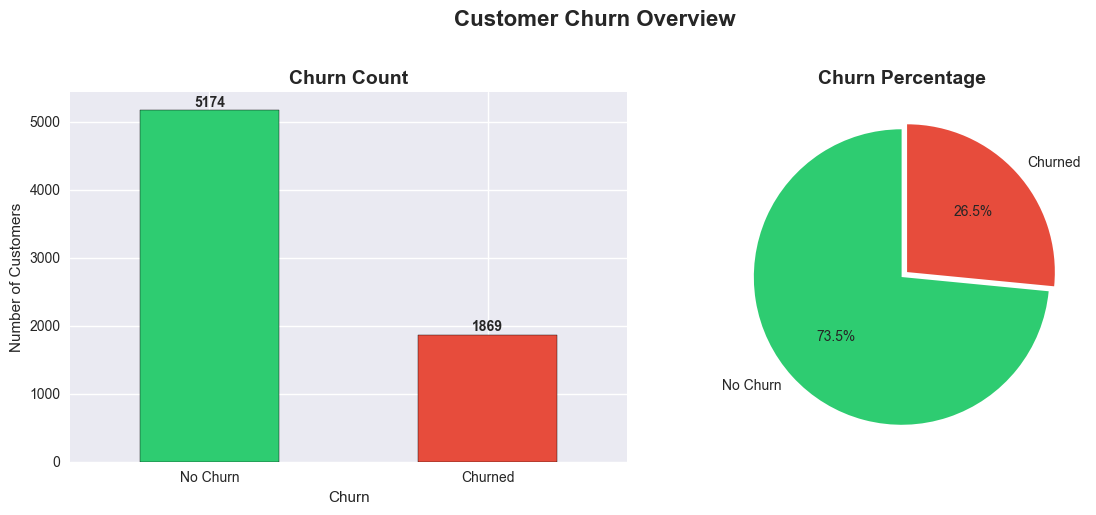

✅ Chart saved to reports/figures/


In [8]:
# ============================================================
# CELL 7 — Churn Distribution Chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Count plot
colors = ['#2ecc71', '#e74c3c']
df_clean['Churn'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    edgecolor='black',
    width=0.5
)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['No Churn', 'Churned'], rotation=0)
for i, v in enumerate(df_clean['Churn'].value_counts()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Chart 2 — Pie chart
axes[1].pie(
    df_clean['Churn'].value_counts(),
    labels=['No Churn', 'Churned'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the chart
save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/01_churn_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to reports/figures/")

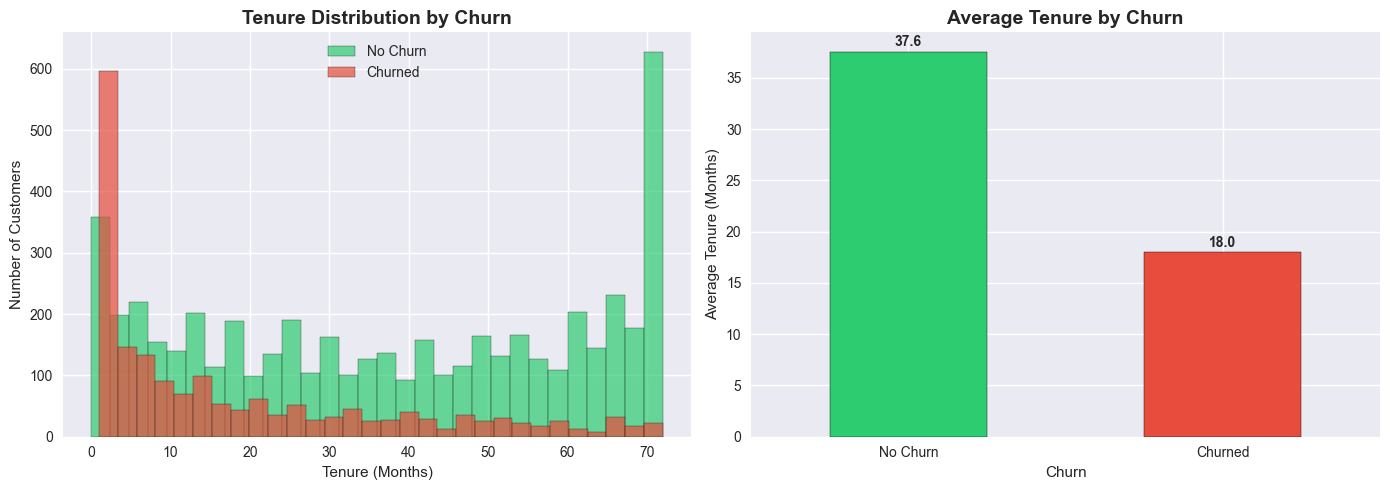

✅ Chart saved!

📊 Business Insight:
Average tenure of churned customers: 18.0 months
Average tenure of loyal customers: 37.6 months


In [9]:
# ============================================================
# CELL 8 — Tenure Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Tenure distribution by churn
df_clean[df_clean['Churn']=='No']['tenure'].hist(
    bins=30, ax=axes[0], color='#2ecc71', 
    alpha=0.7, label='No Churn', edgecolor='black'
)
df_clean[df_clean['Churn']=='Yes']['tenure'].hist(
    bins=30, ax=axes[0], color='#e74c3c', 
    alpha=0.7, label='Churned', edgecolor='black'
)
axes[0].set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Chart 2 — Average tenure by churn
avg_tenure = df_clean.groupby('Churn')['tenure'].mean()
avg_tenure.plot(
    kind='bar', ax=axes[1],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[1].set_title('Average Tenure by Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Average Tenure (Months)')
axes[1].set_xticklabels(['No Churn', 'Churned'], rotation=0)
for i, v in enumerate(avg_tenure):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/02_tenure_analysis.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")
print(f"\n📊 Business Insight:")
print(f"Average tenure of churned customers: {df_clean[df_clean['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"Average tenure of loyal customers: {df_clean[df_clean['Churn']=='No']['tenure'].mean():.1f} months")

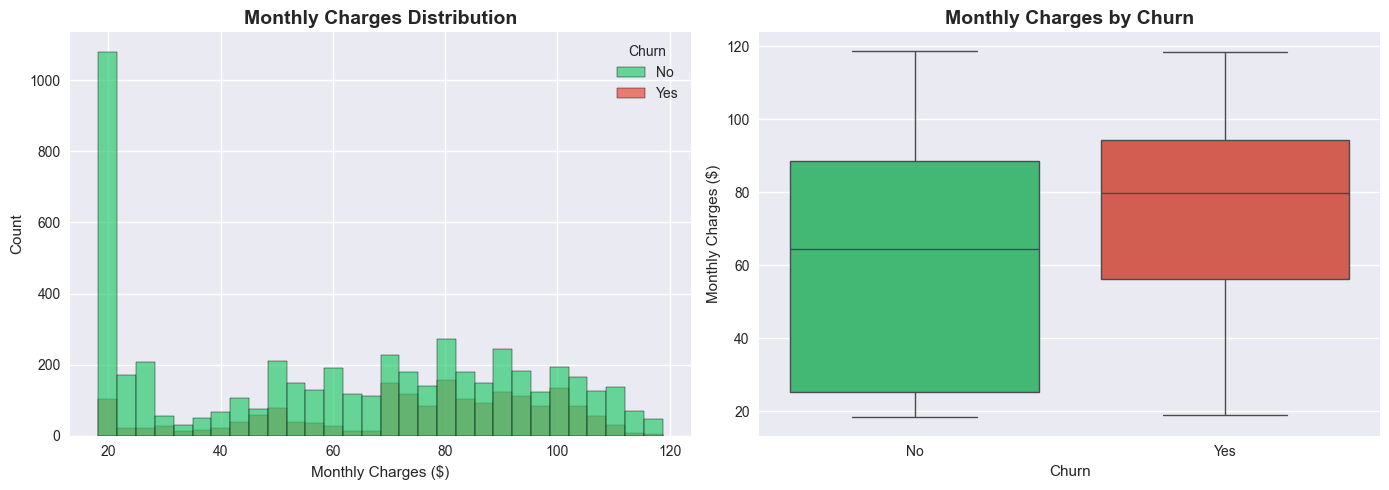

✅ Chart saved!

📊 Business Insight:
Avg monthly charges (churned): $74.44
Avg monthly charges (loyal): $61.27


In [10]:
# ============================================================
# CELL 9 — Monthly Charges Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Monthly charges distribution
sns.histplot(
    data=df_clean, x='MonthlyCharges',
    hue='Churn', bins=30, ax=axes[0],
    palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
    alpha=0.7
)
axes[0].set_title('Monthly Charges Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Count')

# Chart 2 — Boxplot
sns.boxplot(
    data=df_clean, x='Churn', y='MonthlyCharges',
    palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
    ax=axes[1]
)
axes[1].set_title('Monthly Charges by Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/03_monthly_charges.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")
print(f"\n📊 Business Insight:")
print(f"Avg monthly charges (churned): ${df_clean[df_clean['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Avg monthly charges (loyal): ${df_clean[df_clean['Churn']=='No']['MonthlyCharges'].mean():.2f}")

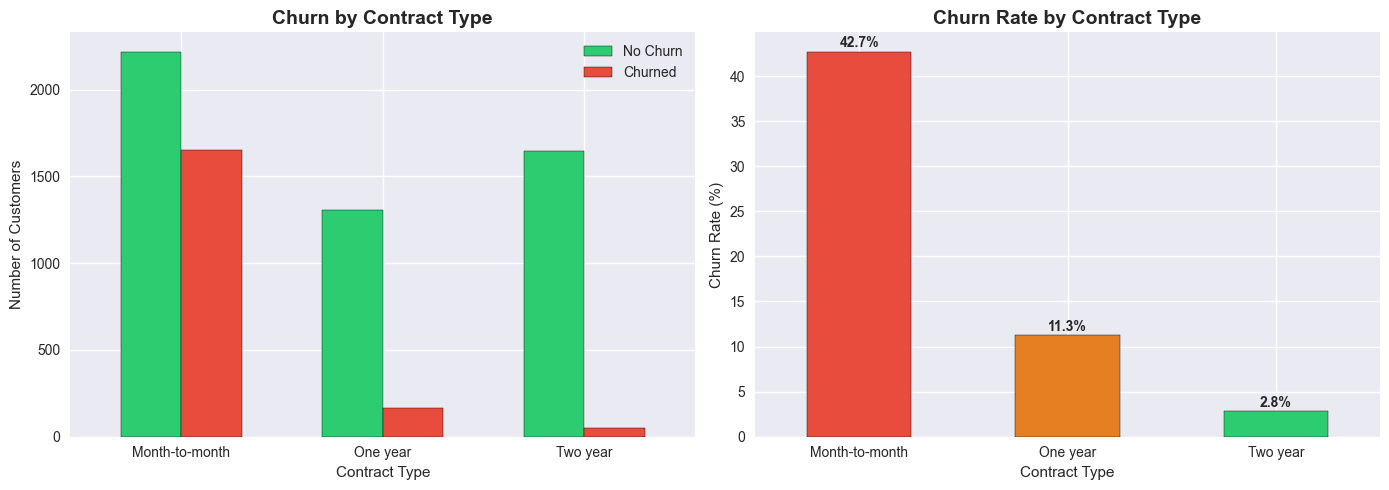

✅ Chart saved!

📊 Business Insight:
Contract
Month-to-month   42.710
One year         11.270
Two year          2.830
Name: Churn, dtype: float64


In [11]:
# ============================================================
# CELL 10 — Contract Type Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Churn by contract type
contract_churn = df_clean.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.6
)
axes[0].set_title('Churn by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['No Churn', 'Churned'])

# Chart 2 — Churn rate by contract type
contract_churn_rate = df_clean.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
)
contract_churn_rate.plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c', '#e67e22', '#2ecc71'],
    edgecolor='black', width=0.5
)
axes[1].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(contract_churn_rate):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/04_contract_analysis.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")
print(f"\n📊 Business Insight:")
print(contract_churn_rate.round(2))

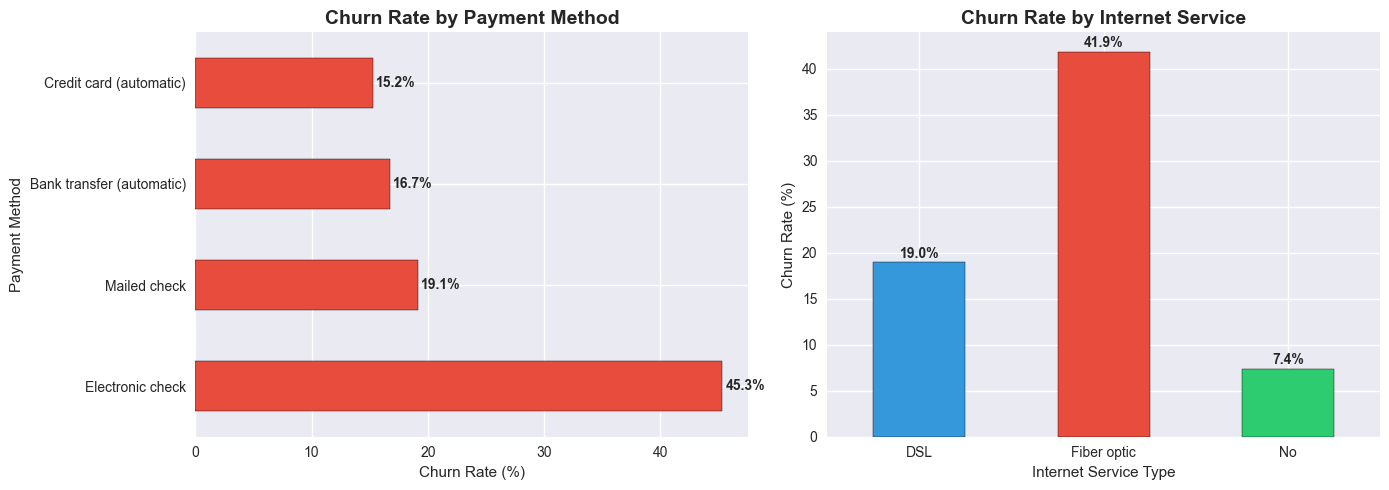

✅ Chart saved!

📊 Payment Method Churn Rates:
PaymentMethod
Electronic check            45.290
Mailed check                19.110
Bank transfer (automatic)   16.710
Credit card (automatic)     15.240
Name: Churn, dtype: float64

📊 Internet Service Churn Rates:
InternetService
DSL           18.960
Fiber optic   41.890
No             7.400
Name: Churn, dtype: float64


In [12]:
# ============================================================
# CELL 11 — Payment Method & Internet Service
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Churn rate by payment method
payment_churn = df_clean.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).sort_values(ascending=False)
payment_churn.plot(
    kind='barh', ax=axes[0],
    color='#e74c3c', edgecolor='black'
)
axes[0].set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_ylabel('Payment Method')
for i, v in enumerate(payment_churn):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

# Chart 2 — Churn rate by internet service
internet_churn = df_clean.groupby('InternetService')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
)
internet_churn.plot(
    kind='bar', ax=axes[1],
    color=['#3498db', '#e74c3c', '#2ecc71'],
    edgecolor='black', width=0.5
)
axes[1].set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Internet Service Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(internet_churn):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/05_payment_internet.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")
print(f"\n📊 Payment Method Churn Rates:")
print(payment_churn.round(2))
print(f"\n📊 Internet Service Churn Rates:")
print(internet_churn.round(2))

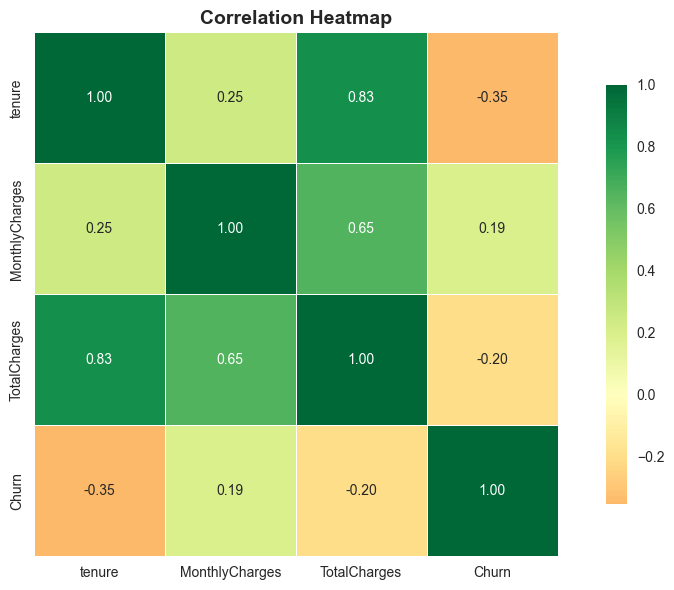

✅ Chart saved!

📊 Correlation with Churn:
Churn             1.000
MonthlyCharges    0.193
TotalCharges     -0.199
tenure           -0.352
Name: Churn, dtype: float64


In [13]:
# ============================================================
# CELL 12 — Correlation Heatmap
# ============================================================

# Convert categorical to numeric for correlation
df_numeric = df_clean.copy()
df_numeric['Churn'] = df_numeric['Churn'].map({'Yes': 1, 'No': 0})

# Select only numeric columns
numeric_cols = df_numeric.select_dtypes(include=[np.number]).columns
corr_matrix = df_numeric[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/06_correlation_heatmap.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")
print("\n📊 Correlation with Churn:")
print(corr_matrix['Churn'].sort_values(ascending=False).round(3))

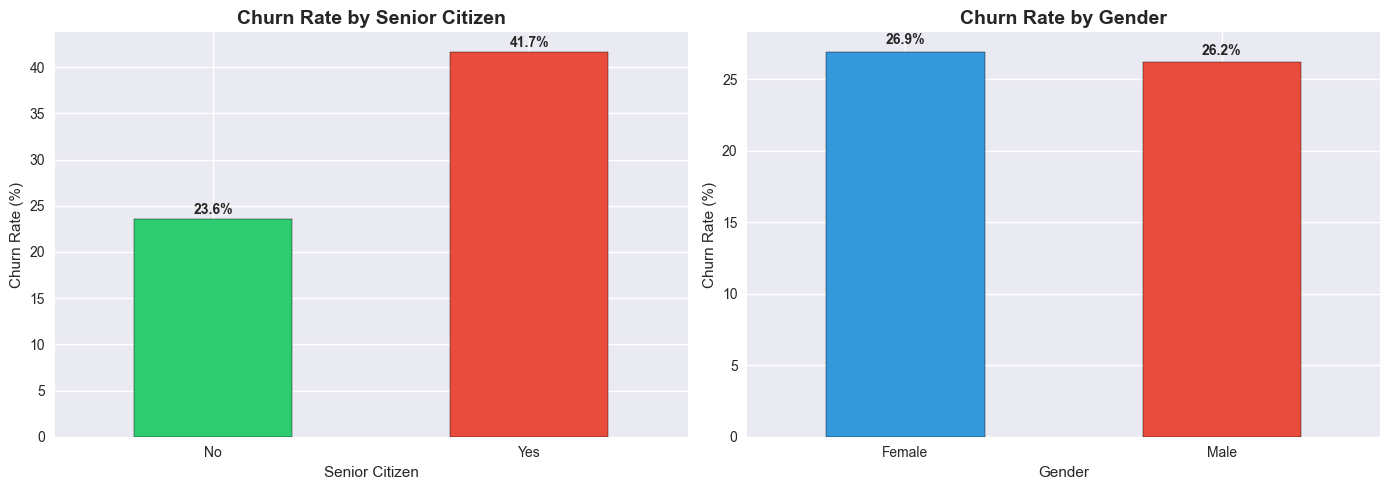

✅ Chart saved!

📊 Senior Citizen Churn Rate:
SeniorCitizen
No    23.610
Yes   41.680
Name: Churn, dtype: float64

📊 Gender Churn Rate:
gender
Female   26.920
Male     26.160
Name: Churn, dtype: float64


In [15]:
# ============================================================
# CELL 13 — Senior Citizen & Gender Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Churn by Senior Citizen
senior_churn = df_clean.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
)
senior_churn.plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[0].set_title('Churn Rate by Senior Citizen', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Senior Citizen')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
for i, v in enumerate(senior_churn):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 2 — Churn by Gender (lowercase 'gender')
gender_churn = df_clean.groupby('gender')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
)
gender_churn.plot(
    kind='bar', ax=axes[1],
    color=['#3498db', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[1].set_title('Churn Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(gender_churn):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/07_senior_gender.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")
print(f"\n📊 Senior Citizen Churn Rate:")
print(senior_churn.round(2))
print(f"\n📊 Gender Churn Rate:")
print(gender_churn.round(2))

In [16]:
# ============================================================
# CELL 14 — EDA Summary & Key Findings
# ============================================================

print("=" * 60)
print("EDA COMPLETE — KEY BUSINESS FINDINGS")
print("=" * 60)

churned = df_clean[df_clean['Churn'] == 'Yes']
loyal = df_clean[df_clean['Churn'] == 'No']

print(f"""
📊 DATASET OVERVIEW
- Total Customers     : {len(df_clean):,}
- Churned Customers   : {len(churned):,} ({len(churned)/len(df_clean)*100:.1f}%)
- Loyal Customers     : {len(loyal):,} ({len(loyal)/len(df_clean)*100:.1f}%)

📉 TENURE INSIGHTS
- Avg tenure (churned): {churned['tenure'].mean():.1f} months
- Avg tenure (loyal)  : {loyal['tenure'].mean():.1f} months

💰 REVENUE INSIGHTS
- Avg monthly charges (churned): ${churned['MonthlyCharges'].mean():.2f}
- Avg monthly charges (loyal)  : ${loyal['MonthlyCharges'].mean():.2f}

⚠️ HIGH RISK SEGMENTS
- Month-to-month contract customers churn the most
- Electronic check payment users churn the most
- Fiber optic internet users churn more than DSL
- Senior citizens have higher churn rate

✅ EDA PHASE COMPLETE — Ready for SQL Analysis!
""")

EDA COMPLETE — KEY BUSINESS FINDINGS

📊 DATASET OVERVIEW
- Total Customers     : 7,043
- Churned Customers   : 1,869 (26.5%)
- Loyal Customers     : 5,174 (73.5%)

📉 TENURE INSIGHTS
- Avg tenure (churned): 18.0 months
- Avg tenure (loyal)  : 37.6 months

💰 REVENUE INSIGHTS
- Avg monthly charges (churned): $74.44
- Avg monthly charges (loyal)  : $61.27

⚠️ HIGH RISK SEGMENTS
- Month-to-month contract customers churn the most
- Electronic check payment users churn the most
- Fiber optic internet users churn more than DSL
- Senior citizens have higher churn rate

✅ EDA PHASE COMPLETE — Ready for SQL Analysis!

